In [ ]:
## Creating the geometry and saving to text file


In [ ]:
import math


def write_rod_txt(
    filename,
    num_nodes,
    spacing=0.01,
    angle_to_vertical_deg=0.0,
    radial_angle_xy_deg=0.0,
):
    """
    Generate a straight rod in 3D.

    Angles:
        angle_to_vertical_deg:
            polar angle from +z axis.
            0 deg  -> along +z
            90 deg -> lies in xy plane

        radial_angle_xy_deg:
            azimuth angle of the rod projection in the xy plane.
            0 deg  -> +x direction
            90 deg -> +y direction

    Coordinates:
        x = r sin(theta) cos(phi)
        y = r sin(theta) sin(phi)
        z = r cos(theta)
    """

    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")

    theta = math.radians(angle_to_vertical_deg)
    phi = math.radians(radial_angle_xy_deg)

    dx = spacing * math.sin(theta) * math.cos(phi)
    dy = spacing * math.sin(theta) * math.sin(phi)
    dz = spacing * math.cos(theta)

    filename = filename.format(angle_to_vertical_deg,radial_angle_xy_deg,num_nodes)


    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for i in range(num_nodes):
            x = i * dx
            y = i * dy
            z = i * dz

            f.write(f"{x:g},{y:g},{z:g}\n")

        f.write("*Edges\n")

        for i in range(1, num_nodes):
            f.write(f"{i},{i + 1}\n")

    print("Saved to:",filename)

# Examples

# # Vertical rod along +z
# write_rod_txt(
#     filename="vertical_z_rod.txt",
#     num_nodes=11,
#     spacing=0.01,
#     angle_to_vertical_deg=0,
#     radial_angle_xy_deg=0,
# )

# # Horizontal rod along +x
# write_rod_txt(
#     filename="horizontal_x_rod.txt",
#     num_nodes=11,
#     spacing=0.01,
#     angle_to_vertical_deg=90,
#     radial_angle_xy_deg=0,
# )

# # Horizontal rod along +y
# write_rod_txt(
#     filename="horizontal_y_rod.txt",
#     num_nodes=11,
#     spacing=0.01,
#     angle_to_vertical_deg=90,
#     radial_angle_xy_deg=90,
# )

# Angled rod: 30 deg away from vertical, projected at 45 deg in xy plane
write_rod_txt(
    filename="../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt",
    num_nodes=11,
    spacing=0.01,
    angle_to_vertical_deg=1,
    radial_angle_xy_deg=0,
)
# write_rod_txt(
#     "../tests/resources/pci/angled_vertical_rod_deg_n11.txt",
#     num_nodes=11,
#     spacing=0.01,
#     angle_to_vertical=10,
# )




# write_rod_txt(
#     filename="../tests/resources/pci/vertical_rod_n11.txt",
#     num_nodes=11,
#     spacing=0.01,
#     orientation="vertical"
# )

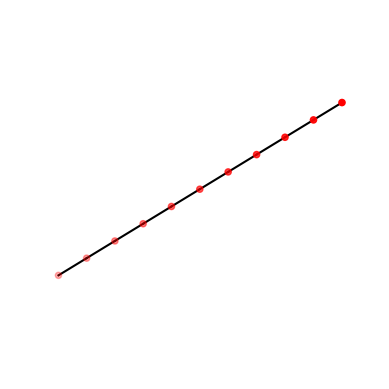

In [124]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=500,
                            youngs_rod=5e4,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dt = 1e-3
static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=dt,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=1)

# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')
geo = dismech.Geometry.from_txt('../tests/resources/pci/angled10v_azi45_rod_n11.txt')


robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [125]:
fixed_points = np.array([0, 1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)


stiffen_s = 100
stiffen_b = 1000

dtrate = 200

nlenEA =  robot.stretch_springs.EA.size
nlenEI = robot.bend_springs.EI.shape[0]
EA0 = robot.stretch_springs.EA[0]*stiffen_s
EI0 = robot.bend_springs.EI[0]*stiffen_b
EA_spatial = np.zeros(nlenEA)


def update_EA(robot: dismech.SoftRobot, t: float):
    tstep =int( t/dt)
    # print("tstep",tstep)
    # print("tstep mod 100",tstep // 100 )

    num_active = min((tstep // dtrate) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate

    current_active = int(np.sum(EA_spatial))

    # Only update if num_active changed
    if num_active > current_active:

        EA_spatial[current_active:num_active] = 1

        # print("num_active:", num_active)
        # print("EA_spatial:", EA_spatial)

        EA_added = np.zeros(nlenEA)
        EA_added[current_active:num_active] = 1

        EI_added = np.zeros((nlenEI,1))
        EI_added[current_active:num_active] = 1

        robot.stretch_springs.EA += EA_added * EA0
        robot.bend_springs.EI += EI_added * EI0

        # print("EI_added:", EI_added * EI0)

    return robot

stepper.before_step = update_EA

robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)
print("EA_spatial:", EA_spatial)

iter: 1, error: 0.022
iter: 2, error: 0.000
current_time:  0.001
iter: 1, error: 0.041
iter: 2, error: 0.000
current_time:  0.002
iter: 1, error: 0.059
iter: 2, error: 0.000
current_time:  0.003
iter: 1, error: 0.075
iter: 2, error: 0.000
current_time:  0.004
iter: 1, error: 0.089
iter: 2, error: 0.000
current_time:  0.005
iter: 1, error: 0.101
iter: 2, error: 0.000
current_time:  0.006
iter: 1, error: 0.111
iter: 2, error: 0.000
current_time:  0.007
iter: 1, error: 0.119
iter: 2, error: 0.000
current_time:  0.008
iter: 1, error: 0.125
iter: 2, error: 0.000
current_time:  0.009000000000000001
iter: 1, error: 0.131
iter: 2, error: 0.000
current_time:  0.010000000000000002
iter: 1, error: 0.134
iter: 2, error: 0.000
current_time:  0.011000000000000003
iter: 1, error: 0.138
iter: 2, error: 0.000
current_time:  0.012000000000000004
iter: 1, error: 0.141
iter: 2, error: 0.000
current_time:  0.013000000000000005
iter: 1, error: 0.145
iter: 2, error: 0.000
current_time:  0.014000000000000005


In [126]:
options = dismech.AnimationOptions(title='Horizontal Rod (N=11))', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()